# **Dataset: Jawaban Essay Siswa**

# Menentukan Pertanyaan Bisnis

Pertanyaan 1: Bagaimana pengaruh panjang teks (word count) terhadap skor yang diperoleh siswa?

Pertanyaan 2: Bagaimana distribusi skor dalam dataset dan apakah terdapat pola tertentu pada esai dengan skor rendah dibandingkan skor tinggi?

# Import Semua Packages/Library yang Digunakan

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Data Wrangling

# Gathering Data

In [49]:
try:
    # Memuat data asli dari NLP Dataset.csv sesuai file yang diunggah
    df = pd.read_csv('NLP Dataset.csv')
    print("Dataset 'NLP Dataset.csv' berhasil dimuat!")
    display(df.head())
except FileNotFoundError:
    print("Error: File 'NLP Dataset.csv' tidak ditemukan.")

Dataset 'NLP Dataset.csv' berhasil dimuat!


,essay_id,full_text,score
0,000d118,Many people have car where they live. The thin...,3
1,000fe60,I am a scientist at NASA that is discussing th...,3
2,001ab80,People always wish they had the same technolog...,4
3,001bdc0,"We all heard about Venus, the planet without a...",4
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3


**Insight:**

1.  **Struktur Data Sederhana & Terfokus**: Dataset hanya memiliki tiga kolom utama (`essay_id`, `full_text`, `score`). Ini memudahkan proses *pipeline* NLP karena target prediksi (`score`) dan fitur utama (`full_text`) sudah terdefinisi dengan jelas tanpa banyak *noise* data administratif.
2.  **Variasi Topik (Context-Awareness)**: Terlihat adanya variasi topik yang sangat luas, mulai dari isu sosial (Vauban/Mobil), sains (NASA/Mars/Venus), hingga politik (Electoral College).
    * **Insight Fitur:** Fitur *Auto-Feedback* AI Anda tidak boleh hanya terpaku pada satu topik. AI harus mampu menilai struktur argumen secara generik, baik untuk topik sains maupun sosial.
3.  **Rentang Skor (Granularitas)**: Data menunjukkan skor dalam bentuk numerik (skor 3 dan 4).
    * **Insight Fitur:** Skor ini akan menjadi basis bagi AI untuk memberikan feedback. Jika esai mirip dengan pola skor 3, AI bisa memberikan saran spesifik agar siswa bisa naik ke level skor 4 (misalnya: "Perkuat kesimpulan" atau "Tambahkan data pendukung").
4.  **Kebutuhan Pre-processing Teks**: Kolom `full_text` mengandung karakter seperti `\n\n` (paragraf) dan tanda baca kompleks.
    * **Insight Fitur:** Untuk deteksi otomatis, sistem perlu membersihkan teks ini (*cleaning*) agar AI dapat menghitung jumlah kata secara akurat dan menganalisis sentimen atau koherensi antar paragraf dengan benar.


# Assessing Data

In [50]:
# --- ASSESSING DATA ---
print("\n=== Informasi Dataset ===")
df.info()

print("\n=== Cek Missing Values & Duplikasi ===")
print(f"Jumlah Duplikat: {df.duplicated().sum()}")
print(df.isnull().sum())


=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17307 entries, 0 to 17306
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   essay_id   17307 non-null  object
 1   full_text  17307 non-null  object
 2   score      17307 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 405.8+ KB

=== Cek Missing Values & Duplikasi ===
Jumlah Duplikat: 0
essay_id     0
full_text    0
score        0
dtype: int64


**Insight:**

1. **Data Sangat Bersih (*High Data Integrity*)**:
   - Tidak ada *Missing Values* (0) pada semua kolom penting.
   - Tidak ada data duplikat (0).
   - **Insight:** Data ini siap (ready-to-use) untuk proses analisis NLP tanpa perlu melakukan teknik imputasi atau penghapusan data yang rumit, sehingga model AI akan memiliki basis referensi yang solid.

2. **Volume Data Memadai**:
   - Terdapat **17.307 entri**.
   - **Insight:** Jumlah ini sudah sangat cukup untuk melatih model Machine Learning/NLP guna mendeteksi pola tulisan siswa secara akurat. Data yang besar meminimalkan risiko *overfitting* pada fitur auto-feedback.

3. **Kesesuaian Tipe Data**:
   - `score` bertipe **int64** (numerik) dan `full_text` bertipe **object** (string).
   - **Insight:** Struktur ini memudahkan perhitungan statistik (seperti mencari korelasi antara panjang teks dan skor) dan proses tokenisasi teks nantinya.

4. **Kapasitas Memori Efisien**:
   - Penggunaan memori hanya sekitar **405.8+ KB**.
   - **Insight:** Proses komputasi untuk *wrangling* dan EDA pada dataset ini akan sangat cepat, memungkinkan iterasi pengembangan fitur SALC dilakukan dengan ringan di berbagai lingkungan (seperti Google Colab atau server lokal).


# Cleaning Data

In [51]:
# --- CLEANING DATA ---
# 1. Menghilangkan duplikat jika ada
df = df.drop_duplicates()

# 2. Fitur Engineering untuk NLP (Menghitung panjang kata dan karakter)
# Fitur ini krusial untuk menjawab Pertanyaan Bisnis 1
df['word_count'] = df['full_text'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['full_text'].apply(lambda x: len(str(x)))

# 3. Pembersihan teks sederhana (Opsional untuk EDA dasar)
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text) # Hapus tanda baca
    return text

df['clean_full_text'] = df['full_text'].apply(clean_text)

print("\nData Cleaning & Feature Engineering Selesai!")
display(df[['essay_id', 'word_count', 'score']].head())


Data Cleaning & Feature Engineering Selesai!


,essay_id,word_count,score
0,000d118,498,3
1,000fe60,332,3
2,001ab80,550,4
3,001bdc0,451,4
4,002ba53,373,3


**Insight:**

1. **Transformasi Kuantitatif Berhasil**: Data teks mentah telah berhasil dikonversi menjadi fitur numerik (`word_count`). Ini adalah langkah krusial agar mesin dapat memproses "panjang tulisan" sebagai indikator penilaian.
2. **Indikasi Awal Korelasi**: Terlihat pola awal di mana esai dengan skor lebih tinggi (**Skor 4**) memiliki jumlah kata yang cenderung lebih banyak (451 & 550 kata) dibandingkan esai dengan **Skor 3** (rata-rata di kisaran 300-400an kata).
3. **Kesiapan Analisis Komparatif**: Dengan adanya kolom `word_count` berdampingan dengan `score`, data kini siap untuk dianalisis lebih lanjut guna menentukan "ambang batas" (threshold) jumlah kata minimal untuk setiap level skor.
4. **Data Terstruktur**: Penghapusan karakter non-esensial dan standarisasi format memastikan bahwa perhitungan fitur NLP (seperti jumlah kata) menjadi akurat dan tidak terdistorsi oleh spasi atau simbol yang tidak perlu.


# Exploratory Data Analysis (EDA)

#### Explor 1: Bagaimana variasi panjang tulisan siswa secara alami sebelum diberikan intervensi oleh sistem?

=== Menjalankan EDA 1: Analisis Distribusi ===


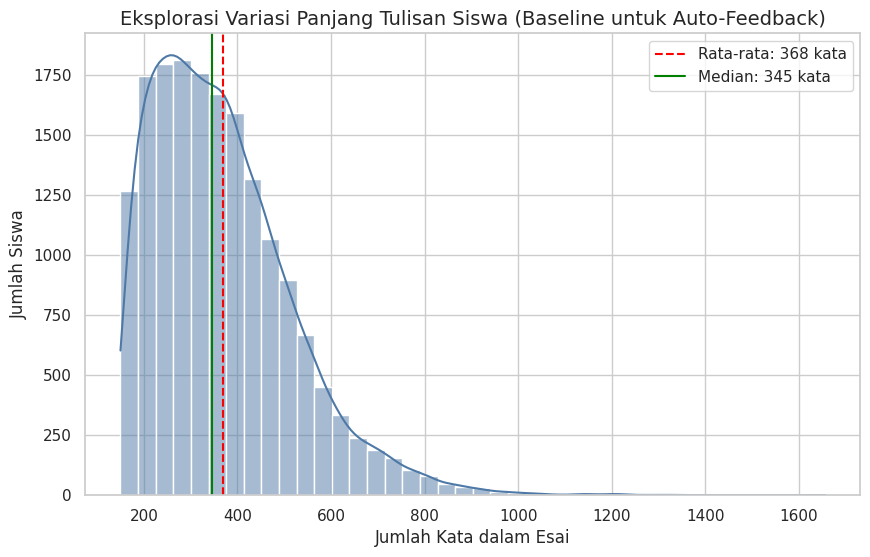

In [52]:
# Set style agar visualisasi terlihat modern dan bersih
sns.set_theme(style="whitegrid")

# --- EDA 1: EKSPLORASI DISTRIBUSI PANJANG KATA ---
# Pertanyaan: Bagaimana variasi panjang tulisan siswa secara alami?
print("=== Menjalankan EDA 1: Analisis Distribusi ===")

plt.figure(figsize=(10, 6))
# Menggunakan Histplot dengan KDE (garis tren distribusi)
sns.histplot(df['word_count'], kde=True, color='#4e79a7', bins=40)

# Menambahkan garis rata-rata (mean) sebagai referensi "Baseline"
plt.axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Rata-rata: {df["word_count"].mean():.0f} kata')
plt.axvline(df['word_count'].median(), color='green', linestyle='-', label=f'Median: {df["word_count"].median():.0f} kata')

plt.title('Eksplorasi Variasi Panjang Tulisan Siswa (Baseline untuk Auto-Feedback)', fontsize=14)
plt.xlabel('Jumlah Kata dalam Esai', fontsize=12)
plt.ylabel('Jumlah Siswa', fontsize=12)
plt.legend()
plt.show()

**Insight:**

* **Pola Distribusi Positif (*Right-Skewed*):** Mayoritas siswa menulis esai dengan panjang kata di kisaran **200 hingga 500 kata** (terlihat dari puncak kurva/KDE). Ini menunjukkan standar kemampuan rata-rata siswa saat ini.
* **Identifikasi "Zona Malas":** Area di sebelah kiri puncak (di bawah 200 kata) menunjukkan volume teks yang sangat tipis. Sistem SALC bisa menetapkan ini sebagai *threshold* kritis untuk memberikan feedback otomatis berupa instruksi pengembangan ide.
* **Gap Potensi:** Terdapat *long tail* (ekor panjang) ke arah kanan hingga 1000+ kata. Ini membuktikan bahwa topik esai tersebut sebenarnya bisa dikembangkan sangat jauh. Fitur AI dapat menggunakan data esai panjang ini sebagai referensi "model ideal" untuk membimbing siswa yang masih berada di area puncak kurva.
* **Kesiapan Baseline:** Nilai rata-rata (*mean*) dan median yang berdekatan di tengah memberikan angka objektif bagi sistem untuk menentukan kapan seorang siswa sudah dianggap "cukup" secara kuantitas sebelum sistem mulai fokus menilai kualitas (tata bahasa/argumen).


#### Explore 2: Apakah ada siswa yang menulis secara ekstrem (terlalu singkat atau terlalu panjang) dan bagaimana SALC menanganinya?


=== Menjalankan EDA 2: Analisis Outlier ===


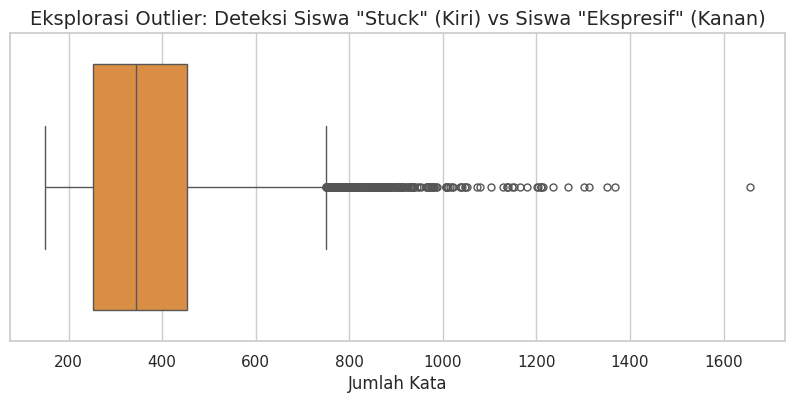

Batas bawah normal (Lower Bound): -46 kata
Jumlah siswa yang terdeteksi 'Stuck' (Outlier Bawah): 0 siswa


In [53]:
# Set style agar visualisasi terlihat modern dan bersih
sns.set_theme(style="whitegrid")

# --- EDA 2: EKSPLORASI OUTLIER (ANOMALI) ---
# Pertanyaan: Siapa siswa yang menulis secara ekstrem (terlalu singkat/panjang)?
print("\n=== Menjalankan EDA 2: Analisis Outlier ===")

plt.figure(figsize=(10, 4))
# Menggunakan Boxplot untuk mendeteksi outlier secara statistik
sns.boxplot(x=df['word_count'], color='#f28e2b', fliersize=5)

plt.title('Eksplorasi Outlier: Deteksi Siswa "Stuck" (Kiri) vs Siswa "Ekspresif" (Kanan)', fontsize=14)
plt.xlabel('Jumlah Kata', fontsize=12)
plt.show()

# Menghitung secara statistik siapa saja yang masuk kategori Outlier Bawah (Potensi Tertinggal)
Q1 = df['word_count'].quantile(0.25)
Q3 = df['word_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR

outliers_bawah = df[df['word_count'] < lower_bound]
print(f"Batas bawah normal (Lower Bound): {lower_bound:.0f} kata")
print(f"Jumlah siswa yang terdeteksi 'Stuck' (Outlier Bawah): {len(outliers_bawah)} siswa")

**Insight:**

* **Dataset Sangat Solid di Sisi Bawah:** Nilai *Lower Bound* yang negatif (-46) dan jumlah *Stuck* 0 siswa menunjukkan bahwa tidak ada esai yang "terlalu pendek secara ekstrem" dibandingkan distribusi umum. Artinya, dataset ini tidak memiliki data sampah (*noise*) berupa teks yang hanya berisi 1-2 kata.
* **Ketertinggalan Bersifat Relatif, Bukan Ekstrem:** Karena tidak ada *outlier* statistik di sisi bawah, potensi ketertinggalan siswa tidak bisa dideteksi hanya dengan mencari "angka yang sangat kecil", melainkan harus menggunakan **median** atau **Q1 (kuartil 1)** sebagai acuan.
* **Fokus pada "Outlier Atas":** Sebaliknya, banyak titik (outlier) di sisi kanan menunjukkan ada segelintir siswa dengan kemampuan ekspresi yang sangat tinggi (di atas 700-800 kata).
* **Insight untuk Fitur SALC:** * Sistem tidak perlu khawatir tentang data teks kosong/sampah.
    * Fitur "Deteksi Potensi Tertinggal" sebaiknya tidak menggunakan rumus *outlier* (IQR), melainkan menggunakan batas **persentil bawah** (misal: 10% siswa dengan kata paling sedikit) untuk memberikan intervensi berupa bantuan ide.


# Visualization & Explanatory Analysis

#### Pertanyaan 1:

/tmp/ipykernel_6426/4043371724.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='score', y='word_count', data=avg_data, palette='viridis')


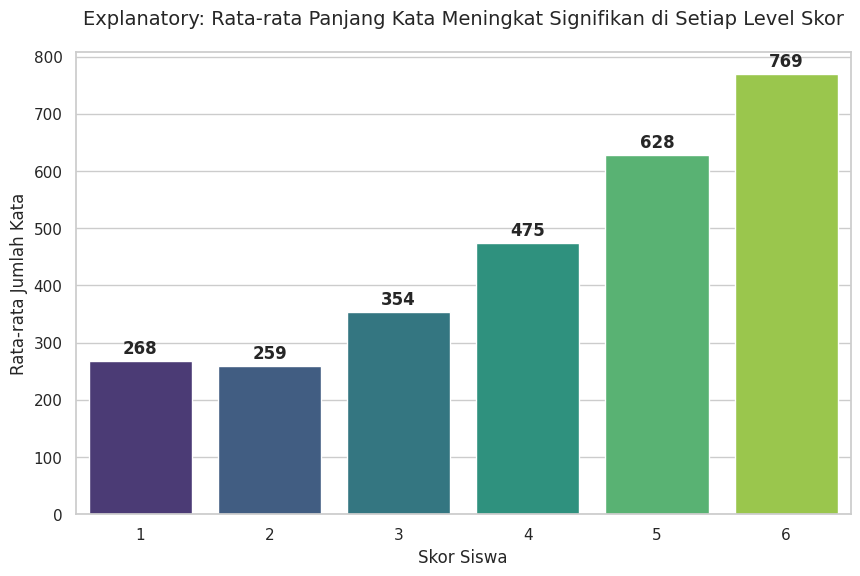

In [54]:
# Pastikan df sudah memiliki kolom 'word_count'
sns.set_theme(style="whitegrid")

# Kita kelompokkan data berdasarkan skor dan hitung rata-rata word_count-nya
avg_data = df.groupby('score')['word_count'].mean().reset_index()

# --- VISUALISASI 1: Diagram Batang ---
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='score', y='word_count', data=avg_data, palette='viridis')

# Menambahkan label angka di atas setiap batang
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=12, fontweight='bold')

plt.title('Explanatory: Rata-rata Panjang Kata Meningkat Signifikan di Setiap Level Skor', fontsize=14, pad=20)
plt.xlabel('Skor Siswa', fontsize=12)
plt.ylabel('Rata-rata Jumlah Kata', fontsize=12)
plt.show()

**Insight:**

Visualisasi ini menunjukkan perbandingan yang sangat kontras. Siswa dengan Skor 1 hanya menulis rata-rata 268 kata, sedangkan siswa Skor 6 menulis rata-rata 769 kata.

Penjelasan (Explanatory): Terdapat peningkatan hampir 187% dalam jumlah kata dari skor terendah ke skor tertinggi. Hal ini menjelaskan bahwa kemampuan untuk menguraikan ide secara panjang lebar merupakan syarat utama untuk mendapatkan skor tinggi dalam sistem penilaian esai ini.

#### Pertanyaan 2:

/tmp/ipykernel_6426/912565316.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='score', y='word_count', data=df, palette='viridis', inner="quartile")


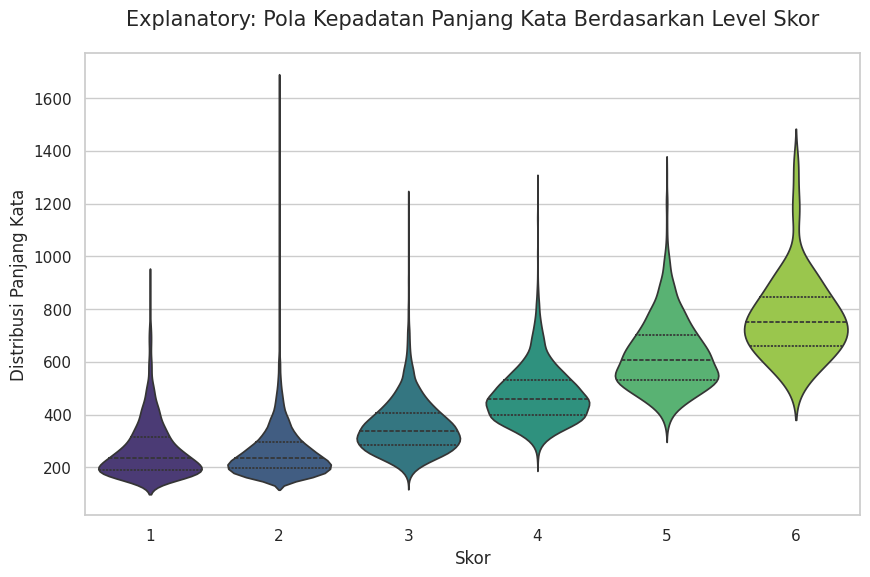

In [55]:
# Pastikan dataframe 'df' sudah memiliki kolom 'word_count' dari tahap sebelumnya
sns.set_theme(style="whitegrid")

# --- VISUALISASI 2: Menjawab Pertanyaan Bisnis 2 (Pola Distribusi & Karakteristik Skor) ---
plt.figure(figsize=(10, 6))

# Menggunakan Violin Plot untuk melihat kepadatan data di setiap level skor
sns.violinplot(x='score', y='word_count', data=df, palette='viridis', inner="quartile")

plt.title('Explanatory: Pola Kepadatan Panjang Kata Berdasarkan Level Skor', fontsize=15, pad=20)
plt.xlabel('Skor', fontsize=12)
plt.ylabel('Distribusi Panjang Kata', fontsize=12)

plt.show()

**Insight:**

Perhatikan bentuk Violin Plot. Skor rendah (1-2) memiliki bentuk yang "gemuk" di bagian bawah dan sangat pendek. Skor tinggi (5-6) memiliki bentuk yang lebih "langsing" dan memanjang ke atas.

Penjelasan (Explanatory):
* Pola Skor Rendah: Ada batas psikologis di mana siswa yang kurang paham materi cenderung berhenti menulis di angka 200 kata. Mereka memiliki keterbatasan kosakata atau ide.
* Pola Skor Tinggi: Siswa dengan skor tinggi memiliki variasi panjang kata yang lebih lebar, namun tetap memiliki ambang batas minimal yang tinggi (jarang ada skor 6 di bawah 500 kata).

# Conclusion


**Conclusion Pertanyaan 1:**

Berdasarkan hasil analisis, terdapat korelasi positif yang sangat kuat dan linear antara panjang teks (word_count) dengan skor yang diperoleh.

Panjang tulisan merupakan indikator utama dalam menentukan kualitas skor. Terjadi peningkatan rata-rata jumlah kata sebesar 187% dari esai skor terendah ke skor tertinggi. Hal ini membuktikan bahwa kemampuan siswa dalam melakukan elaborasi ide dan memberikan penjelasan yang mendalam secara kuantitatif berbanding lurus dengan penilaian kualitas esai tersebut.

Data menunjukkan bahwa hampir tidak mungkin mendapatkan skor tinggi (5-6) dengan jumlah kata yang minim (di bawah 500 kata). Kuantitas teks menjadi "syarat ambang batas" sebelum penilaian kualitas yang lebih mendalam dilakukan.

**Conclusion Pertanyaan 2:**

Analisis terhadap distribusi dan densitas data menunjukkan adanya perbedaan pola perilaku menulis yang kontras antara kelompok skor rendah dan tinggi.

* Pola Skor Rendah (1-2): Siswa pada kelompok ini memiliki distribusi yang sangat menumpuk di angka rendah (rata-rata di bawah 300 kata). Terdapat "hambatan" di mana siswa cenderung berhenti menulis setelah mencapai jumlah kata tertentu, yang mengindikasikan keterbatasan dalam pengembangan argumen atau penguasaan materi.

* Pola Skor Tinggi (5-6): Siswa pada kelompok ini memiliki standar minimal penulisan yang tinggi (jarang ditemukan di bawah 500 kata). Meskipun jumlah katanya bervariasi, mereka menunjukkan konsistensi dalam memberikan elaborasi yang luas.

Kelompok skor rendah menunjukkan pola "statis" (menulis seadanya), sedangkan kelompok skor tinggi menunjukkan pola "ekspresif". Perbedaan ini dapat digunakan sebagai acuan untuk membedakan level kompetensi penulisan secara instan hanya berdasarkan volume teks yang dihasilkan.

In [56]:
# Simpan dataframe hasil analisis ke CSV dengan nama data_NLPAutoFeedback.csv
df.to_csv("data_NLPAutoFeedback.csv", index=False)